# 03 -- Probability Calibration: Model Comparison

**Contact Luck Prototype v0.1**

Why calibration matters more here than plain ranking accuracy: the luck score is built from the *magnitude* of predicted probabilities (`expected_value = sum(p(outcome) * value(outcome))`), not just which outcome is most likely. A model that ranks outcomes correctly but assigns systematically over- or under-confident probabilities will produce biased raw-luck values even when its classification-style metrics look fine.

**Background:** an earlier baseline trained `LogisticRegression(class_weight="balanced")` and, on real 2021-2024 Statcast data, produced severely miscalibrated probabilities -- e.g. rows called ~54% likely to be a triple were observed to be a triple ~3.6% of the time, on a bin with thousands of samples. This notebook runs the full controlled comparison that diagnosed and fixed this (see `mlb_luck_score.models.compare_models` and CLAUDE.md).

Running this notebook successfully is **not** evidence that a given variant is well-calibrated in general -- judge that from the actual numbers below, which reflect the data present when you run it.

> **Do not calculate or publish Luck Scores until the selected model has acceptably calibrated probabilities.**

> **This repository is a research prototype, not a validated public baseball statistic.** See `README.md` and `CLAUDE.md` for full scope and limitations.

In [1]:
import pandas as pd

from mlb_luck_score.config import PROCESSED_DATA_DIR
from mlb_luck_score.models.compare_models import (
    VARIANT_CLASS_BALANCED,
    VARIANT_NAIVE_PREVALENCE,
    VARIANT_UNWEIGHTED,
    VARIANT_UNWEIGHTED_CALIBRATED,
    build_comparison_summary_table,
    run_comparison,
)

DEVELOPMENT_PATH = PROCESSED_DATA_DIR / "cleaned_development_data.parquet"
pd.set_option("display.width", 160)

In [2]:
if DEVELOPMENT_PATH.exists():
    df = pd.read_parquet(DEVELOPMENT_PATH)
    print(f"Loaded full development dataset: {len(df)} rows")
else:
    df = None
    print(
        f"No full development dataset found at {DEVELOPMENT_PATH}.\n"
        "This comparison needs multiple real seasons (2021-2024) -- the one-week "
        "sample is not enough. Run `make download-development-data` then "
        "`make clean-development-data`, then re-run this notebook."
    )

Loaded full development dataset: 494173 rows


## Run the controlled comparison

Four variants, same untouched 2024 validation season for the first three (`unweighted`, `class_balanced_comparison_only`, `naive_prevalence` all train on 2021-2023); the fourth uses a time-ordered post-hoc-calibration design (base train on 2021-2022, calibration fit on 2023, evaluation on 2024 -- three non-overlapping season groups, see `mlb_luck_score.config.CALIBRATION_BASE_TRAIN_SEASONS`/`CALIBRATION_FIT_SEASONS`/`CALIBRATION_EVAL_SEASONS`).

In [3]:
if df is not None:
    try:
        results = run_comparison(df, include_post_hoc_calibration=True)
        summary = build_comparison_summary_table(results)
    except ValueError as exc:
        results = None
        summary = None
        print(f"Skipped -- {exc}")
else:
    results = summary = None

6 of 41 calibration bin(s) have fewer than 20 samples and are marked unreliable.
Training with class_weight='balanced' (class_balanced_comparison_only). This variant is a labeled COMPARISON MODEL ONLY -- its predicted probabilities are known to be severely miscalibrated and must NOT be used for the Contact Luck score.
4 of 47 calibration bin(s) have fewer than 20 samples and are marked unreliable.
1 of 28 calibration bin(s) have fewer than 20 samples and are marked unreliable.


Training with class_weight='balanced' (class_balanced_comparison_only). This variant is a labeled COMPARISON MODEL ONLY -- its predicted probabilities are known to be severely miscalibrated and must NOT be used for the Contact Luck score.


4 of 47 calibration bin(s) have fewer than 20 samples and are marked unreliable.


1 of 28 calibration bin(s) have fewer than 20 samples and are marked unreliable.


## Summary: log loss, expected calibration error (ECE), accuracy, Brier, recall

In [4]:
if summary is not None:
    display(summary)
    print(
        "\nLog loss / ECE / Brier: LOWER is better (probability quality).\n"
        "Accuracy / recall: HIGHER is better, but this is a SEPARATE concern from "
        "calibration -- see the recall-vs-calibration note below."
    )
else:
    print("Skipped -- no comparison results available.")

,variant,sample_count,multiclass_log_loss,expected_calibration_error,argmax_accuracy,brier_out,brier_single,brier_double,brier_triple,brier_home_run,recall_out,recall_single,recall_double,recall_triple,recall_home_run
0,unweighted,122132,0.670321,0.014413,0.751457,0.165917,0.137869,0.052472,0.005608,0.017203,0.917733,0.417229,0.189820,0.001439,0.712344
1,class_balanced_comparison_only,122132,1.078047,0.134029,0.548742,0.284009,0.157697,0.070634,0.041056,0.021588,0.562637,0.510744,0.328608,0.428777,0.847355
2,naive_prevalence,122132,0.936884,0.001788,0.675097,0.219354,0.166537,0.059506,0.005658,0.042592,1.000000,0.000000,0.000000,0.000000,0.000000
3,unweighted_post_hoc_calibrated,122132,0.723148,0.047540,0.699284,0.186092,0.143789,0.057095,0.005640,0.018011,0.991801,0.000000,0.000000,0.000000,0.666789



Log loss / ECE / Brier: LOWER is better (probability quality).
Accuracy / recall: HIGHER is better, but this is a SEPARATE concern from calibration -- see the recall-vs-calibration note below.


### Recall is not calibration

Watch `recall_triple` and `recall_home_run` alongside `expected_calibration_error` above: `class_balanced_comparison_only` typically shows HIGHER recall on rare classes (it is tuned to predict them more often) but a MUCH WORSE `expected_calibration_error` and `multiclass_log_loss` than `unweighted`. Good recall on a rare class from a class-weighted model does not mean its predicted *probabilities* for that class are trustworthy -- for a luck metric, which needs the probability magnitude (not just the argmax prediction), calibration is what matters.

## Calibration table detail: triple, single, double, home_run

In [5]:
if results is not None:
    for entry in results:
        table = pd.DataFrame(entry["calibration_table"])
        if table.empty:
            continue
        print(f"\n=== {entry['variant']} ===")
        subset = table[table["outcome_class"].isin(["triple", "single", "double", "home_run"])]
        subset = subset[subset["sample_count"] >= 500]
        display(subset[["outcome_class", "bin_low", "bin_high", "mean_predicted_probability", "observed_frequency", "sample_count", "abs_calibration_error", "reliable"]])
else:
    print("Skipped -- no comparison results available.")


=== unweighted ===


,outcome_class,bin_low,bin_high,mean_predicted_probability,observed_frequency,sample_count,abs_calibration_error,reliable
10,single,0.0,0.1,0.038554,0.044468,41693,0.005914,True
11,single,0.1,0.2,0.156898,0.152545,14068,0.004354,True
12,single,0.2,0.3,0.248354,0.227182,40791,0.021171,True
13,single,0.3,0.4,0.347300,0.250065,7686,0.097234,True
14,single,0.4,0.5,0.452006,0.631756,8899,0.179750,True
15,single,0.5,0.6,0.543844,0.581595,8150,0.037751,True
16,single,0.6,0.7,0.622912,0.271429,840,0.351484,True
18,double,0.0,0.1,0.030291,0.030638,98995,0.000347,True
19,double,0.1,0.2,0.138555,0.129723,12041,0.008832,True
20,double,0.2,0.3,0.247029,0.206057,5712,0.040972,True



=== class_balanced_comparison_only ===


,outcome_class,bin_low,bin_high,mean_predicted_probability,observed_frequency,sample_count,abs_calibration_error,reliable
10,single,0.0,0.1,0.042066,0.010154,33977,0.031912,True
11,single,0.1,0.2,0.145131,0.150185,16513,0.005054,True
12,single,0.2,0.3,0.252699,0.397650,9873,0.144951,True
13,single,0.3,0.4,0.359684,0.335195,23992,0.024489,True
14,single,0.4,0.5,0.441272,0.246069,31922,0.195204,True
15,single,0.5,0.6,0.546010,0.631000,3271,0.084990,True
16,single,0.6,0.7,0.644526,0.483117,1925,0.161409,True
17,single,0.7,0.8,0.735237,0.219436,638,0.515802,True
19,double,0.0,0.1,0.052493,0.014979,45663,0.037513,True
20,double,0.1,0.2,0.144156,0.044896,37353,0.099260,True



=== naive_prevalence ===


,outcome_class,bin_low,bin_high,mean_predicted_probability,observed_frequency,sample_count,abs_calibration_error,reliable
1,single,0.2,0.3,0.210430,0.211099,122132,0.000669,True
2,double,0.0,0.1,0.065886,0.063538,122132,0.002348,True
3,triple,0.0,0.1,0.005550,0.005691,122132,0.000140,True
4,home_run,0.0,0.1,0.046696,0.044575,122132,0.002122,True



=== unweighted_post_hoc_calibrated ===


,outcome_class,bin_low,bin_high,mean_predicted_probability,observed_frequency,sample_count,abs_calibration_error,reliable
10,single,0.0,0.1,0.022850,0.013090,31703,0.009760,True
11,single,0.1,0.2,0.152115,0.114215,6050,0.037901,True
12,single,0.2,0.3,0.244814,0.157218,53270,0.087596,True
13,single,0.3,0.4,0.309120,0.523996,31109,0.214877,True
14,double,0.0,0.1,0.066607,0.049103,111908,0.017504,True
15,double,0.1,0.2,0.129522,0.212861,9875,0.083339,True
17,triple,0.0,0.1,0.006183,0.005691,122132,0.000492,True
18,home_run,0.0,0.1,0.003061,0.001857,109872,0.001204,True
19,home_run,0.1,0.2,0.145190,0.094516,2243,0.050673,True
20,home_run,0.2,0.3,0.252264,0.193394,2089,0.058870,True


## Expected calibration error by class

In [6]:
if results is not None:
    ece_by_class = pd.DataFrame({r["variant"]: r["expected_calibration_error_by_class"] for r in results})
    display(ece_by_class)
else:
    print("Skipped -- no comparison results available.")

,unweighted,class_balanced_comparison_only,naive_prevalence,unweighted_post_hoc_calibrated
double,0.004039,0.105884,0.002348,0.023516
home_run,0.002706,0.020061,0.002122,0.007894
out,0.031353,0.323759,0.003660,0.108449
single,0.033749,0.084764,0.000669,0.097350
triple,0.000218,0.135678,0.000140,0.000492


## Calibration plots (saved under outputs/figures/model_comparison/<variant>/)

unweighted -> ['/Users/arihantaneja/Downloads/TrueLuckMLBStat/outputs/figures/model_comparison_nb03/unweighted/calibration_out.png', '/Users/arihantaneja/Downloads/TrueLuckMLBStat/outputs/figures/model_comparison_nb03/unweighted/calibration_single.png', '/Users/arihantaneja/Downloads/TrueLuckMLBStat/outputs/figures/model_comparison_nb03/unweighted/calibration_double.png', '/Users/arihantaneja/Downloads/TrueLuckMLBStat/outputs/figures/model_comparison_nb03/unweighted/calibration_triple.png', '/Users/arihantaneja/Downloads/TrueLuckMLBStat/outputs/figures/model_comparison_nb03/unweighted/calibration_home_run.png']


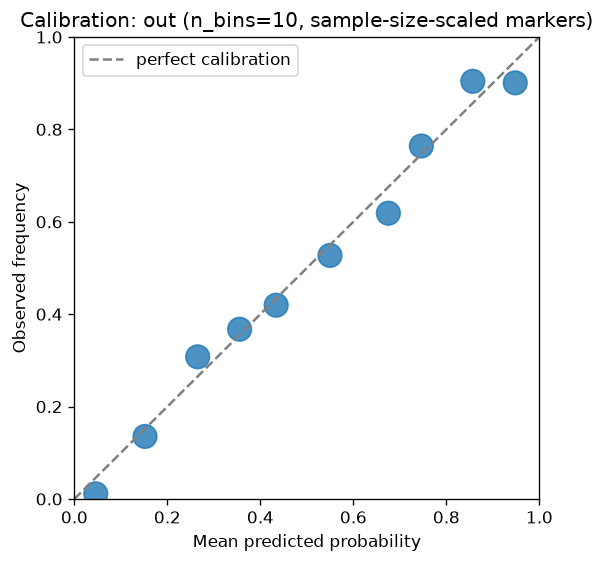

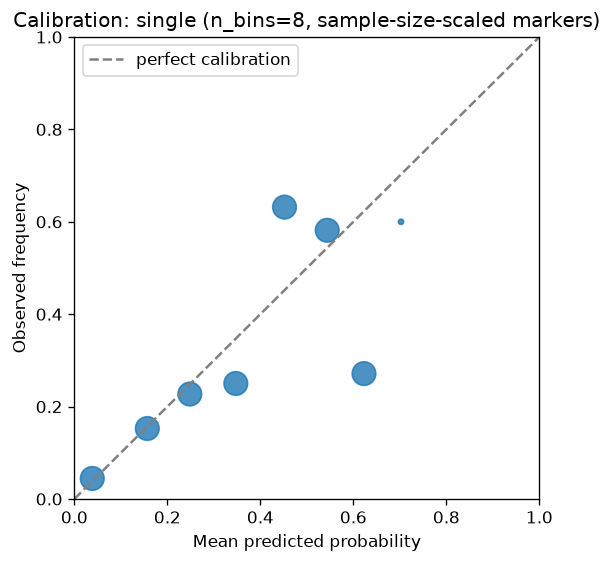

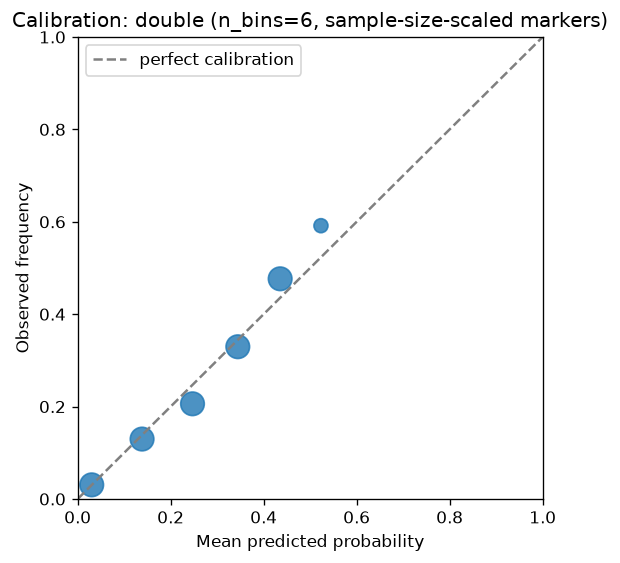

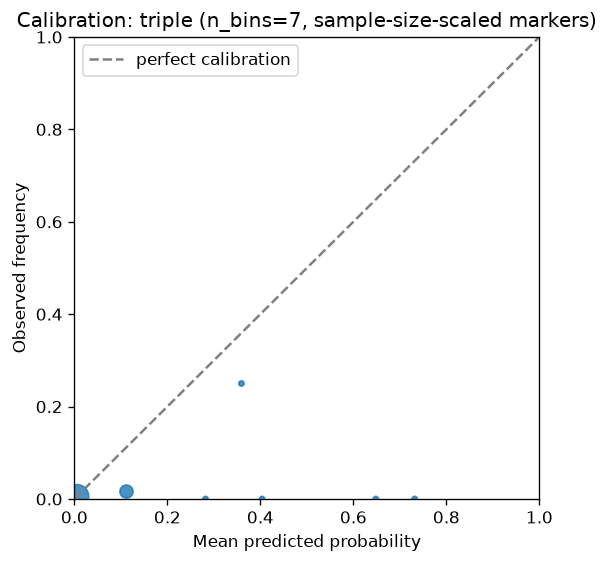

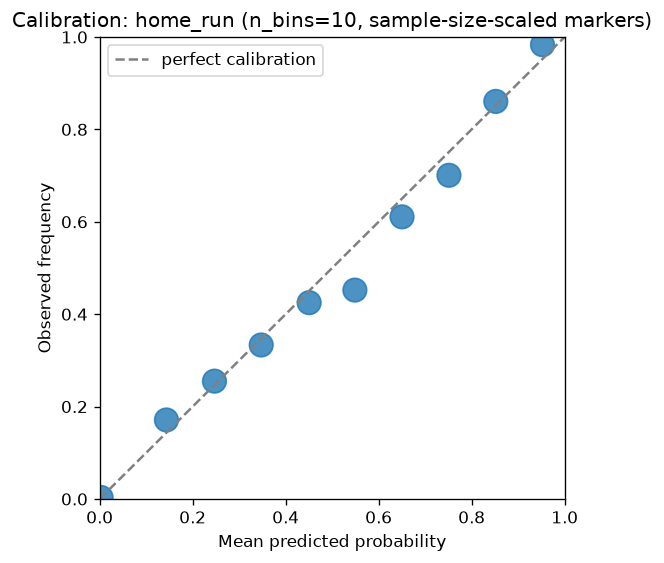

class_balanced_comparison_only -> ['/Users/arihantaneja/Downloads/TrueLuckMLBStat/outputs/figures/model_comparison_nb03/class_balanced_comparison_only/calibration_out.png', '/Users/arihantaneja/Downloads/TrueLuckMLBStat/outputs/figures/model_comparison_nb03/class_balanced_comparison_only/calibration_single.png', '/Users/arihantaneja/Downloads/TrueLuckMLBStat/outputs/figures/model_comparison_nb03/class_balanced_comparison_only/calibration_double.png', '/Users/arihantaneja/Downloads/TrueLuckMLBStat/outputs/figures/model_comparison_nb03/class_balanced_comparison_only/calibration_triple.png', '/Users/arihantaneja/Downloads/TrueLuckMLBStat/outputs/figures/model_comparison_nb03/class_balanced_comparison_only/calibration_home_run.png']


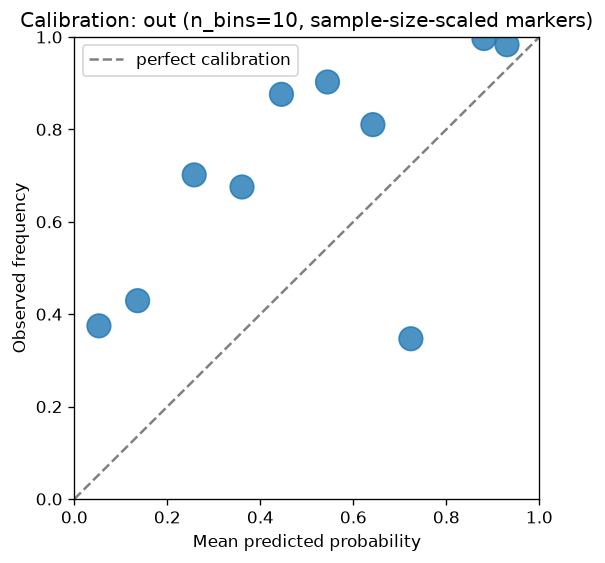

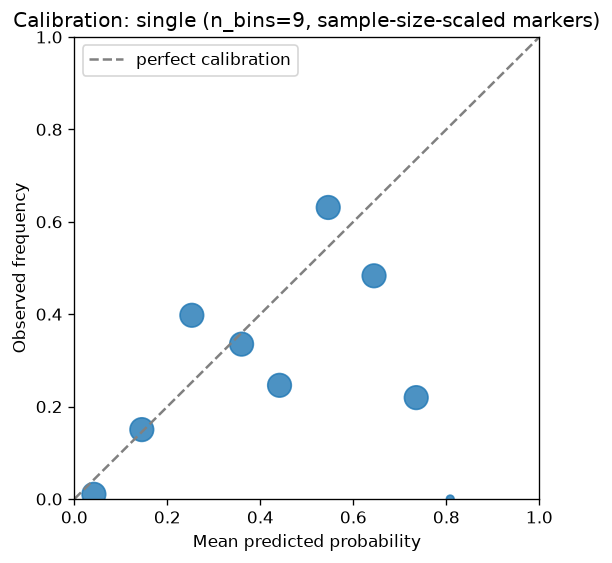

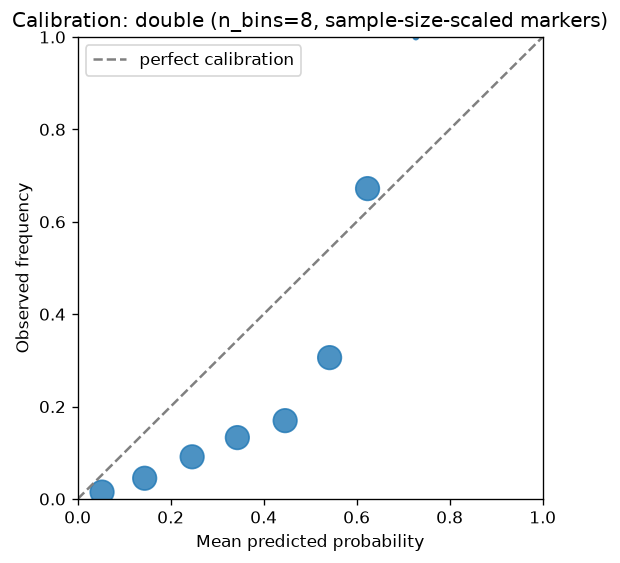

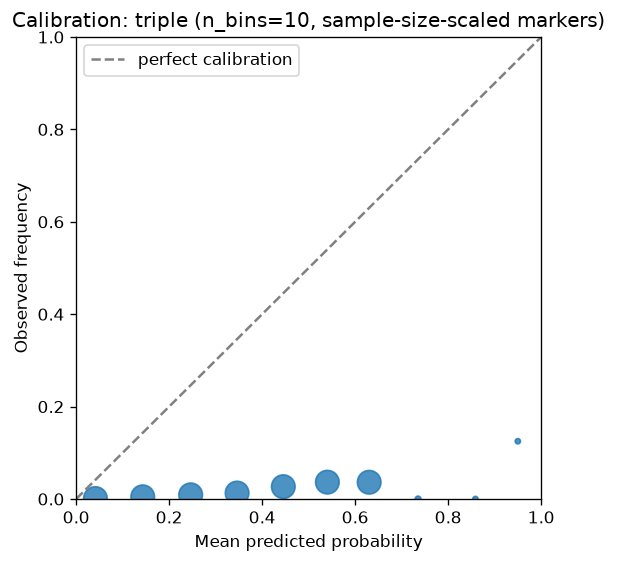

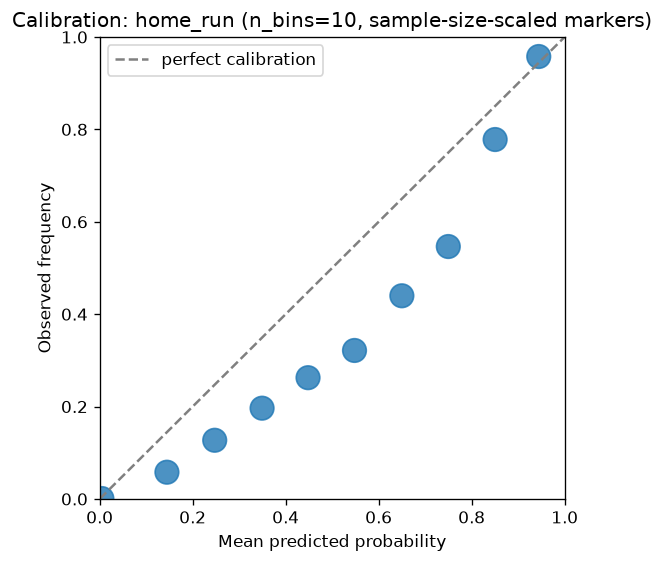

naive_prevalence -> ['/Users/arihantaneja/Downloads/TrueLuckMLBStat/outputs/figures/model_comparison_nb03/naive_prevalence/calibration_out.png', '/Users/arihantaneja/Downloads/TrueLuckMLBStat/outputs/figures/model_comparison_nb03/naive_prevalence/calibration_single.png', '/Users/arihantaneja/Downloads/TrueLuckMLBStat/outputs/figures/model_comparison_nb03/naive_prevalence/calibration_double.png', '/Users/arihantaneja/Downloads/TrueLuckMLBStat/outputs/figures/model_comparison_nb03/naive_prevalence/calibration_triple.png', '/Users/arihantaneja/Downloads/TrueLuckMLBStat/outputs/figures/model_comparison_nb03/naive_prevalence/calibration_home_run.png']


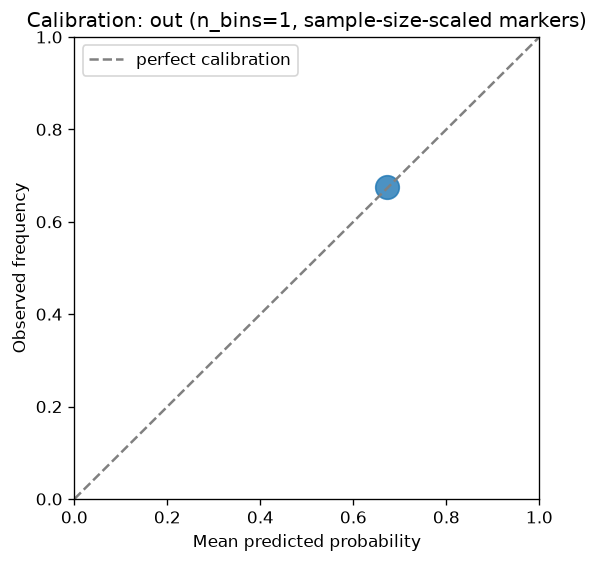

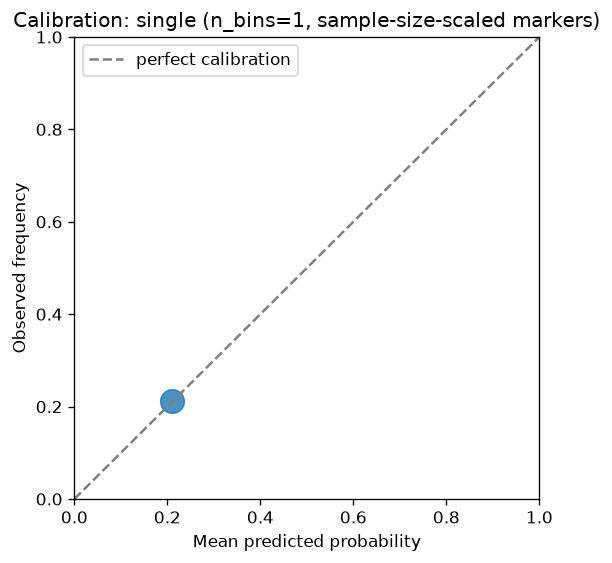

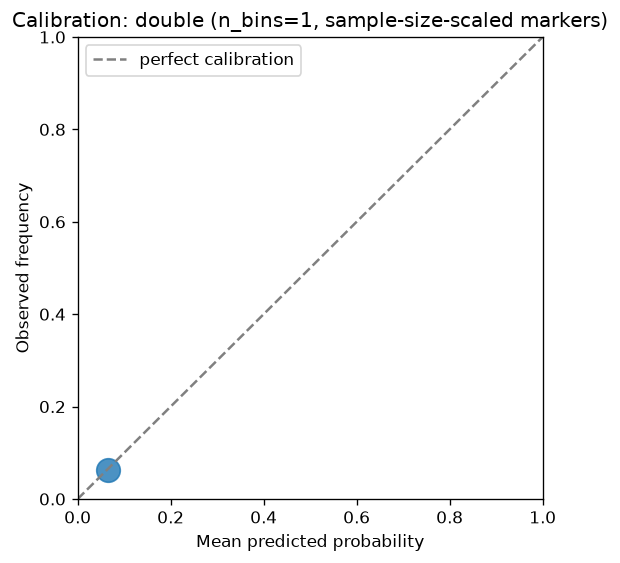

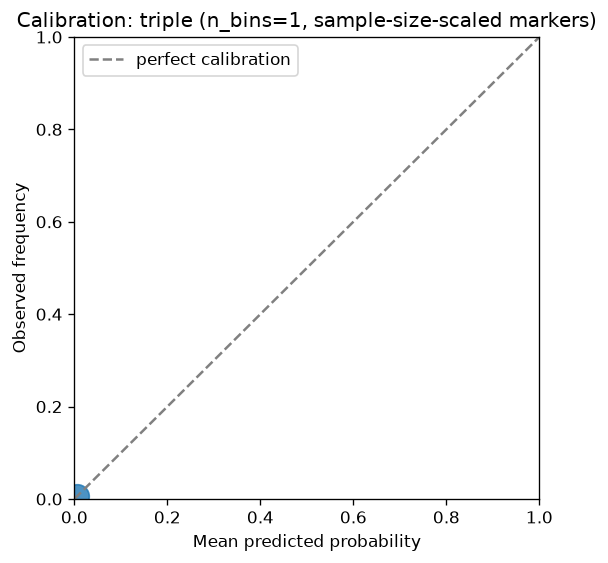

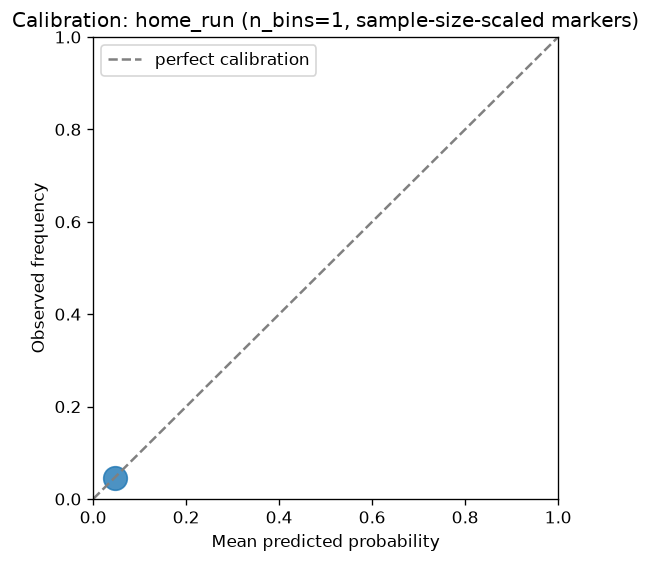

unweighted_post_hoc_calibrated -> ['/Users/arihantaneja/Downloads/TrueLuckMLBStat/outputs/figures/model_comparison_nb03/unweighted_post_hoc_calibrated/calibration_out.png', '/Users/arihantaneja/Downloads/TrueLuckMLBStat/outputs/figures/model_comparison_nb03/unweighted_post_hoc_calibrated/calibration_single.png', '/Users/arihantaneja/Downloads/TrueLuckMLBStat/outputs/figures/model_comparison_nb03/unweighted_post_hoc_calibrated/calibration_double.png', '/Users/arihantaneja/Downloads/TrueLuckMLBStat/outputs/figures/model_comparison_nb03/unweighted_post_hoc_calibrated/calibration_triple.png', '/Users/arihantaneja/Downloads/TrueLuckMLBStat/outputs/figures/model_comparison_nb03/unweighted_post_hoc_calibrated/calibration_home_run.png']


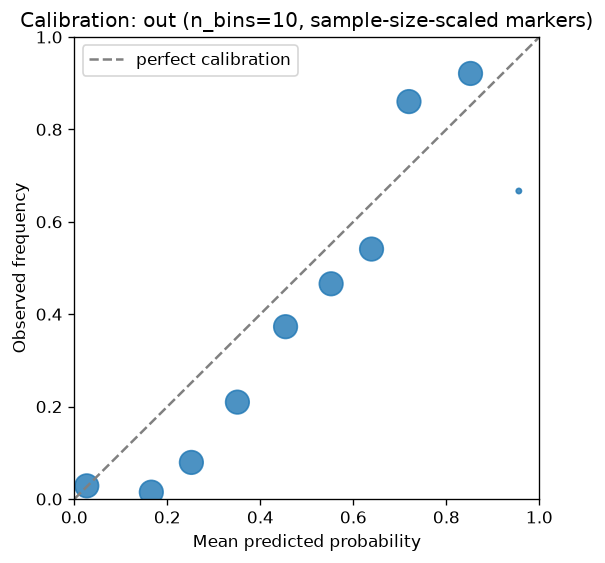

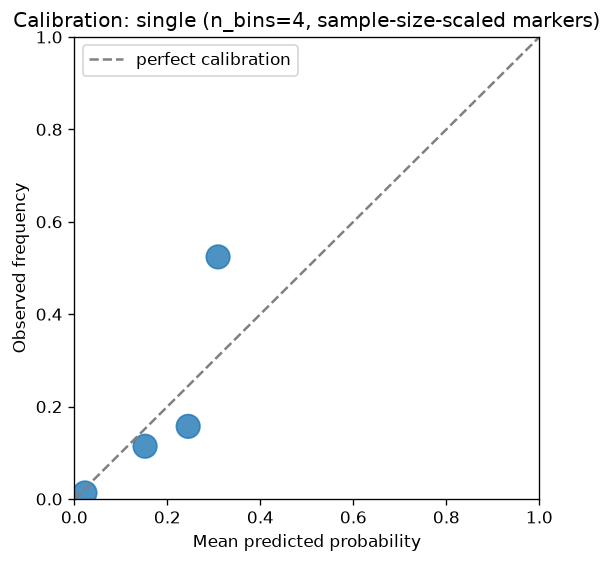

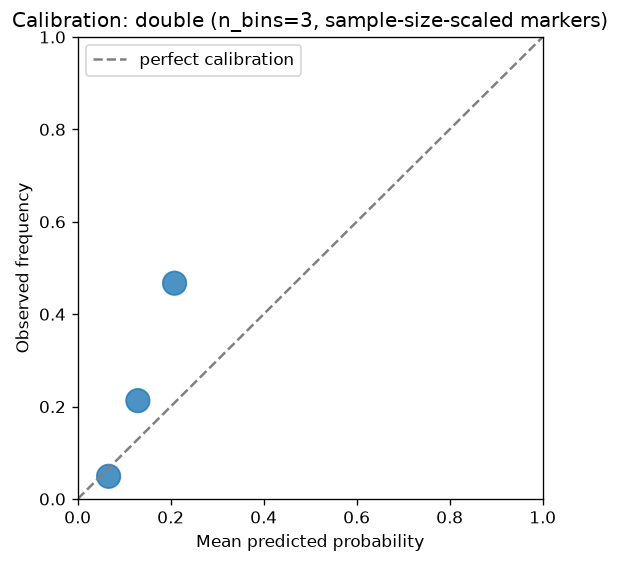

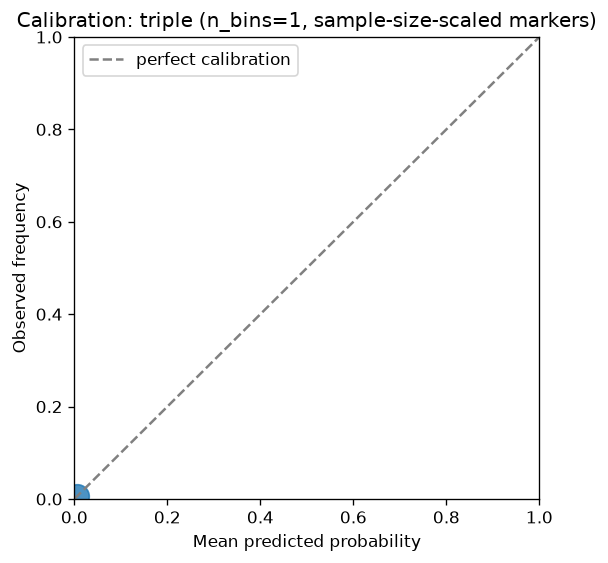

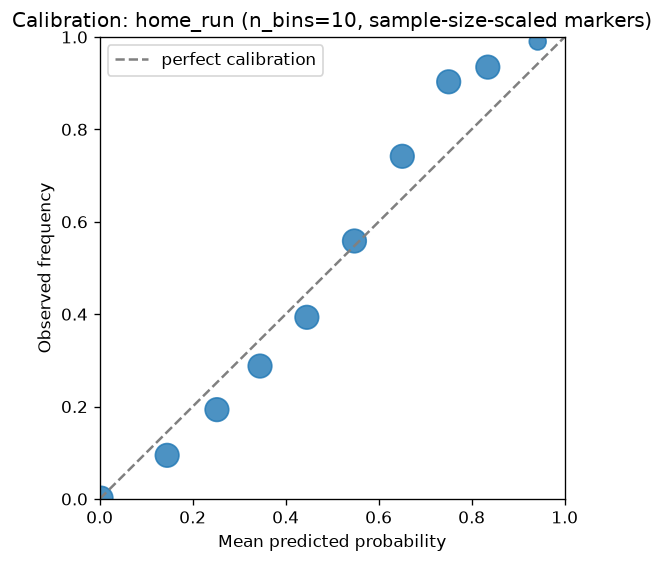

In [7]:
if results is not None:
    from pathlib import Path
    from IPython.display import Image, display as ipy_display
    from mlb_luck_score.config import FIGURES_DIR
    from mlb_luck_score.models.calibrate_model import compute_calibration_table, plot_calibration_curves

    figures_root = FIGURES_DIR / "model_comparison_nb03"
    for entry in results:
        table = pd.DataFrame(entry["calibration_table"])
        if table.empty:
            continue
        paths = plot_calibration_curves(table, figures_root / entry["variant"])
        print(entry["variant"], "->", [str(p) for p in paths])
        for path in paths:
            ipy_display(Image(filename=str(path)))
else:
    print("Skipped -- no comparison results available.")

## Interpretation warnings

- `naive_prevalence` (ignores every feature) can show a lower aggregate ECE than a real model -- it is trivially "calibrated on average" by construction, but has no discrimination (its per-class Brier scores are correspondingly worse). A real model should beat it on log loss / Brier, not necessarily on raw ECE alone.
- Bins with few samples (see the `reliable` column) can show large calibration error by chance -- do not over-interpret single-digit-sample bins.
- Post-hoc calibration is not guaranteed to help: if the base model is already reasonably calibrated, an added isotonic/sigmoid layer fit on a smaller slice of data can introduce its own noise. Compare `unweighted` against `unweighted_post_hoc_calibrated` above rather than assuming the calibrated version is better.
- Never fit a calibrator and evaluate it on the same rows -- `unweighted_post_hoc_calibrated` above is fit on `CALIBRATION_FIT_SEASONS` (2023) and evaluated on `CALIBRATION_EVAL_SEASONS` (2024), which are disjoint.
- This notebook's numbers are whatever your current data produces -- re-run it after any data or feature change rather than trusting a cached result.

## Recommendation

Based on the metrics computed above (log loss, ECE, and per-class calibration tables), the **unweighted** model (`class_weight=None`) is the candidate Contact Luck probability baseline: it should show both the lowest log loss and a much smaller ECE than `class_balanced_comparison_only`, while still beating `naive_prevalence` on log loss and Brier score. `class_balanced_comparison_only` must not be used for scoring regardless of any recall advantage it shows. Do not proceed to computing or publishing Luck Scores until you've confirmed these numbers look acceptable on your own data -- and even then, treat this as a Version 0.1 finding to revisit, not a final validated result.